# CREDIT CARD FRAUD DETECTION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\CODSOFT_DATASCIENCE\\creditcard.csv')
# Display basic information about the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (284807, 31)

Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

Data Types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
missing = df.isnull().sum()
print("\nMissing Values:\n", missing[missing > 0])


Missing Values:
 Series([], dtype: int64)


In [4]:
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)


Duplicate Rows: 1081


In [5]:
df = df.drop_duplicates()

In [6]:
df.shape

(283726, 31)


Class Distribution:
 Class
0    283253
1       473
Name: count, dtype: int64


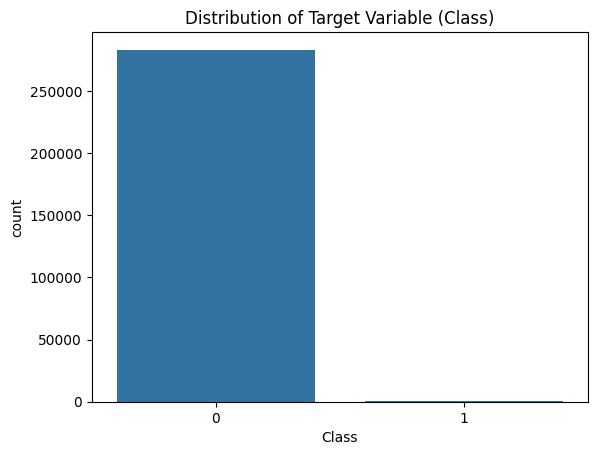

In [8]:
print("\nClass Distribution:\n", df['Class'].value_counts())
# Visualize the distribution of the target variable
sns.countplot(x='Class', data=df)
plt.title('Distribution of Target Variable (Class)')
plt.show()

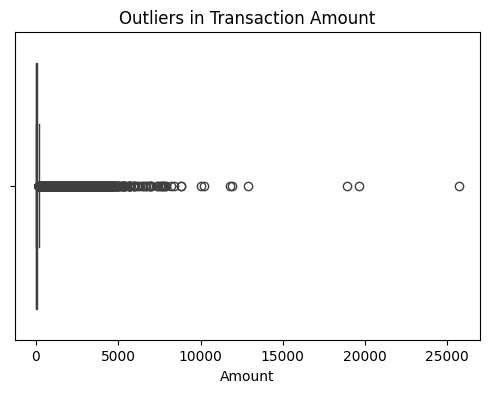

In [9]:
# 7. OUTLIER CHECK (Amount)
# =========================
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Amount'])
plt.title("Outliers in Transaction Amount")
plt.show()

In [10]:
# 8. FEATURE SCALING
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [11]:
# Scale Amount and Time (important!)
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

In [12]:
df_eda = df.copy()   # for visualization
df_model = df.copy() # for ML

# Clean only df_model
df_model = df_model.drop(['Time', 'Amount'], axis=1)

# DROP AMOUNT & TIME FROM df

In [13]:
# 9. DROP ORIGINAL COLUMNS
# =========================
df = df.drop(['Amount', 'Time'], axis=1)

In [14]:
# 10. FINAL CLEAN DATA CHECK
# =========================
print("\nFinal Shape:", df.shape)
print("\nAny Null Values Left?\n", df.isnull().sum().sum())

df.head()


Final Shape: (283726, 31)

Any Null Values Left?
 0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


In [15]:
# Check skewness of Amount
print("Skewness of Amount:", df['Amount_scaled'].skew())

Skewness of Amount: 16.978803370060483


# Exploratory Data Analysis

### To analyze the number of fraud vs genuine cases
#### FRAUD IS ENCODED 1
#### NOT FRAUD ENCODED 0

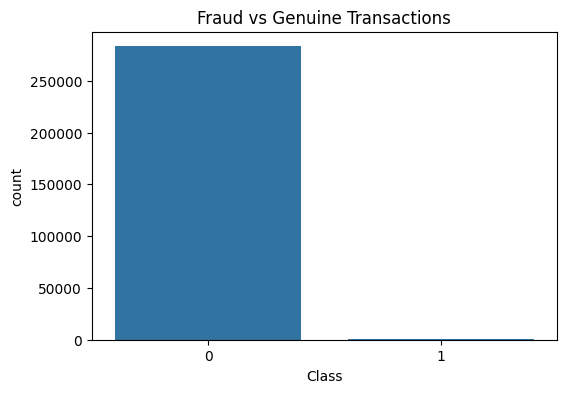

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

print(df['Class'].value_counts(normalize=True))

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
! python -m pip install shap

import shap

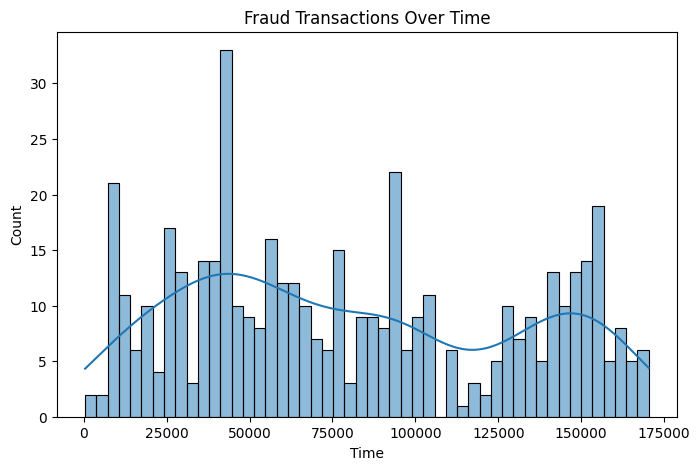

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df_eda[df_eda['Class']==1]['Time'], bins=50, kde=True)
plt.title("Fraud Transactions Over Time")
plt.show()

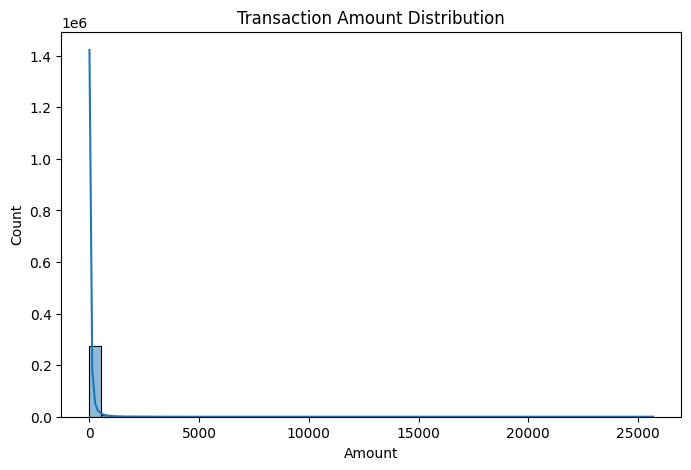

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df_eda['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

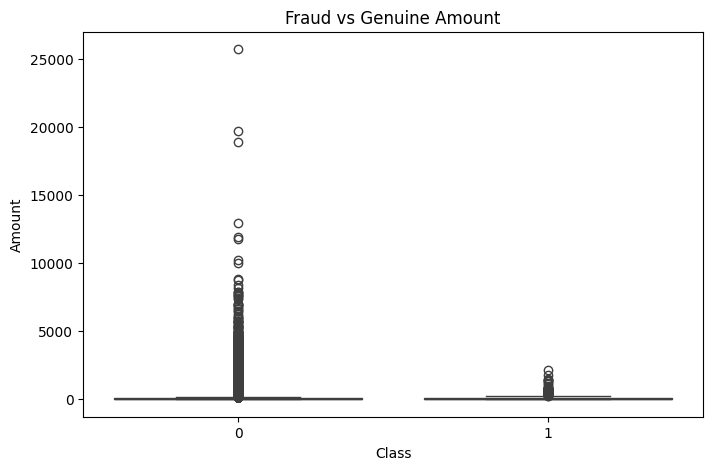

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df_eda)
plt.title("Fraud vs Genuine Amount")
plt.show()

In [30]:
import numpy as np
def cap_outliers_classwise(df_eda, column):
    df_new = df_eda.copy()

    for cls in df_eda['Class'].unique():
        mask = df_new['Class'] == cls
        df_cls = df_new[mask]

        Q1 = df_cls[column].quantile(0.25)
        Q3 = df_cls[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_new.loc[mask, column] = np.clip(df_cls[column], lower, upper)

    return df_new

df_eda = cap_outliers_classwise(df_eda, 'Amount')

In [31]:
print("Before:", df_eda.shape)
print("After:", df.shape)

Before: (223826, 33)
After: (283726, 31)


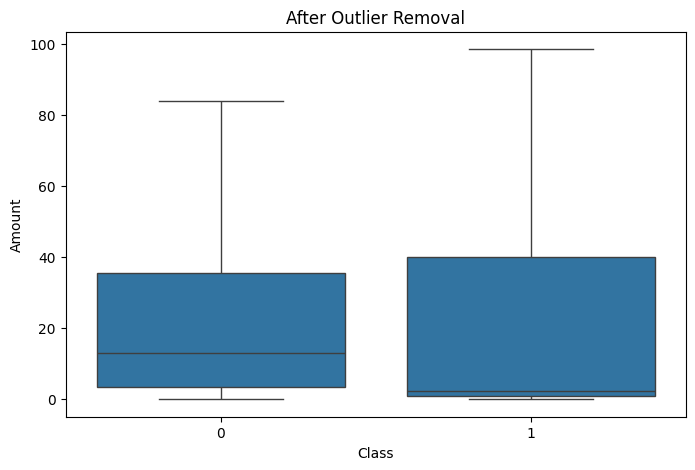

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df_eda)  # use cleaned df
plt.title("After Outlier Removal")
plt.show()

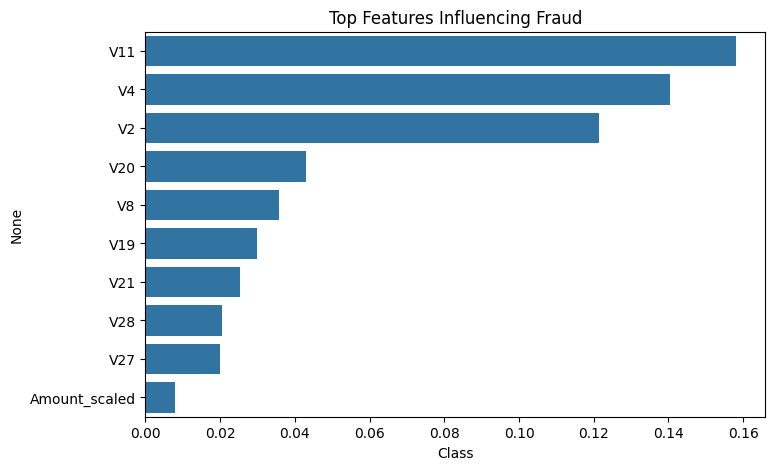

In [33]:
corr = df_eda.corr()['Class'].sort_values(ascending=False)

top_features = corr.index[1:11]

plt.figure(figsize=(8,5))
sns.barplot(x=corr[top_features], y=top_features)
plt.title("Top Features Influencing Fraud")
plt.show()

## Preprocessing

In [34]:
scaler = StandardScaler()
df_eda['Amount'] = scaler.fit_transform(df_eda[['Amount']])

X = df_eda.drop('Class', axis=1)
y = df_eda['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:

# SELECT IMPORTANT FEATURES
# =========================
corr = df_eda.corr()['Class'].sort_values(ascending=False)

# pick top 2 features (excluding Class)
features = corr.index[1:3]

f1, f2 = features[0], features[1]

print("Selected features:", f1, f2)

Selected features: V11 V4


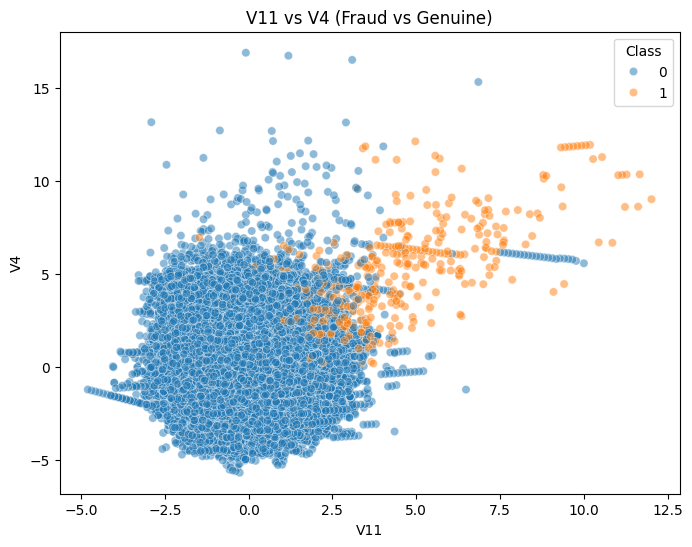

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df[f1],
    y=df[f2],
    hue=df['Class'],
    alpha=0.5
)

plt.title(f"{f1} vs {f2} (Fraud vs Genuine)")
plt.show()

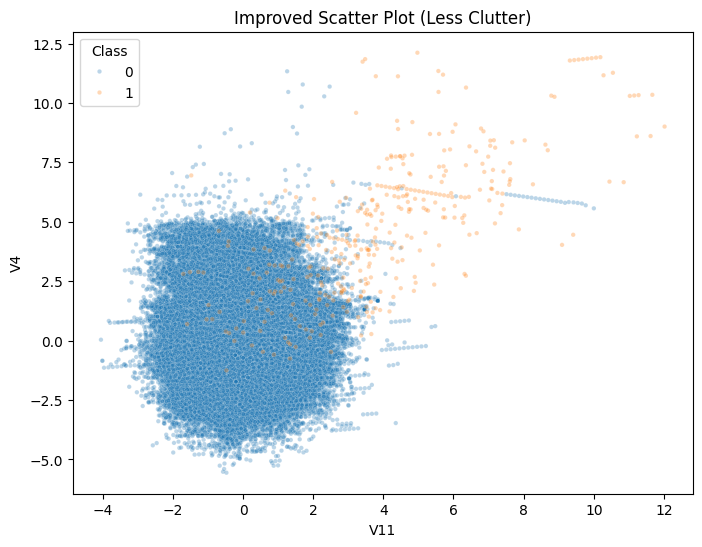

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_eda['V11'],
    y=df_eda['V4'],
    hue=df_eda['Class'],
    alpha=0.3,   # reduce opacity
    s=10         # smaller points
)

plt.title("Improved Scatter Plot (Less Clutter)")
plt.show()

In [39]:
df_fraud = df_eda[df_eda['Class'] == 1]
df_nonfraud = df_eda[df_eda['Class'] == 0].sample(len(df_fraud), random_state=42)

df_vis = pd.concat([df_fraud, df_nonfraud])

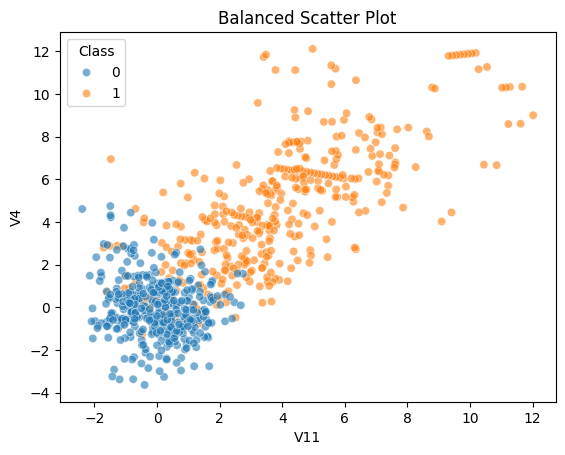

In [40]:
sns.scatterplot(
    x=df_vis['V11'],
    y=df_vis['V4'],
    hue=df_vis['Class'],
    alpha=0.6
)
plt.title("Balanced Scatter Plot")
plt.show()

In [41]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

X_vis = df_vis[['V11', 'V4']]
y_vis = df_vis['Class']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_vis)

model = LogisticRegression(max_iter=1000)
model.fit(X_poly, y_vis)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

c:\Users\Shipra\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


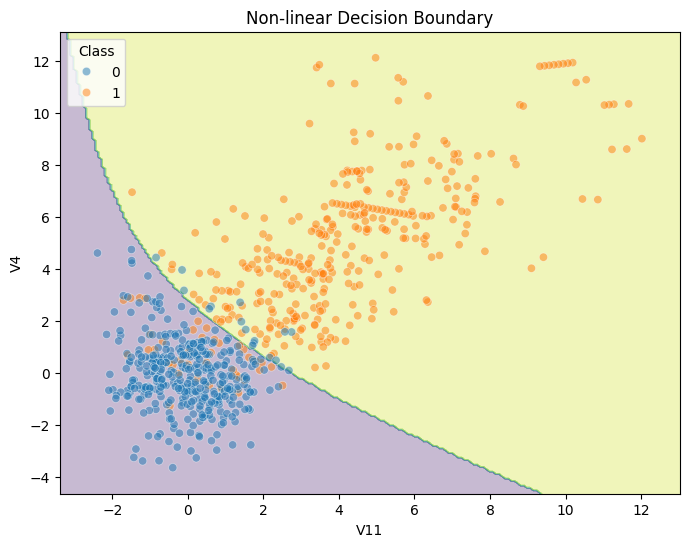

In [42]:
x_min, x_max = X_vis['V11'].min()-1, X_vis['V11'].max()+1
y_min, y_max = X_vis['V4'].min()-1, X_vis['V4'].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(poly.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

sns.scatterplot(x=X_vis['V11'], y=X_vis['V4'], hue=y_vis, alpha=0.5)

plt.title("Non-linear Decision Boundary")
plt.show()

## Handling imbalance

In [44]:
# =========================
# FEATURES & TARGET
# =========================
X = df_eda.drop('Class', axis=1)
y = df_eda['Class']

# =========================
# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,      # increase iterations
    solver='lbfgs'      # stable solver
)

lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [55]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_res)
X_test_poly = poly.transform(X_test)

# SCALE (very important)
scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train_poly)
X_test_poly = scaler_poly.transform(X_test_poly)

# Model
lr_poly = LogisticRegression(max_iter=5000)
lr_poly.fit(X_train_poly, y_train_res)

# Predictions
y_pred_poly = lr_poly.predict(X_test_poly)
y_prob_poly = lr_poly.predict_proba(X_test_poly)[:,1]

In [52]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [53]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10,
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [56]:
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
print("Polynomial LR\n", classification_report(y_test, y_pred_poly))
print("Random Forest\n", classification_report(y_test, y_pred_rf))
print("XGBoost\n", classification_report(y_test, y_pred_xgb))

Logistic Regression
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     44690
           1       0.18      0.89      0.30        76

    accuracy                           0.99     44766
   macro avg       0.59      0.94      0.65     44766
weighted avg       1.00      0.99      1.00     44766

Polynomial LR
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     44690
           1       0.30      0.80      0.43        76

    accuracy                           1.00     44766
   macro avg       0.65      0.90      0.72     44766
weighted avg       1.00      1.00      1.00     44766

Random Forest
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     44690
           1       0.90      0.83      0.86        76

    accuracy                           1.00     44766
   macro avg       0.95      0.91      0.93     44766
weighted avg       1.00

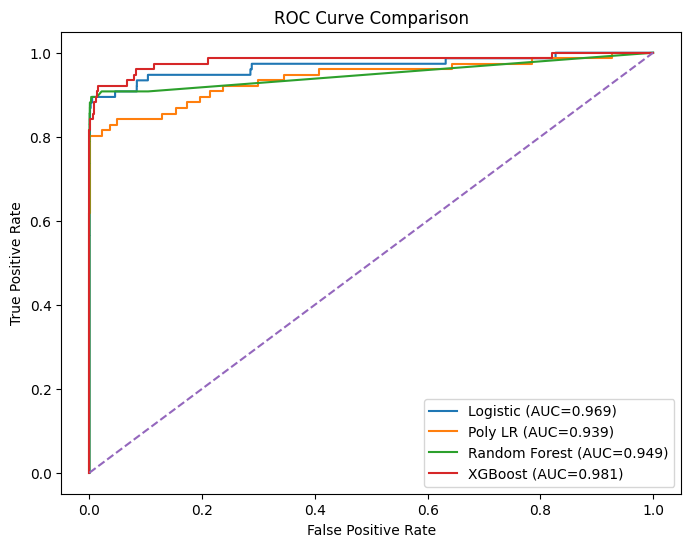

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

models = {
    "Logistic": y_prob_lr,
    "Poly LR": y_prob_poly,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

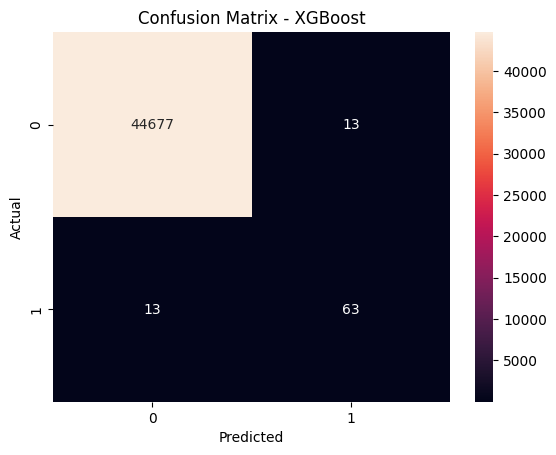

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

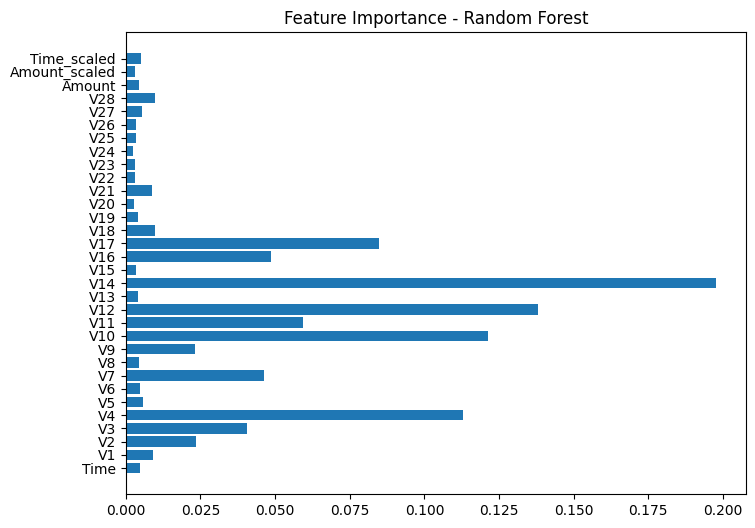

In [59]:
importances = rf.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

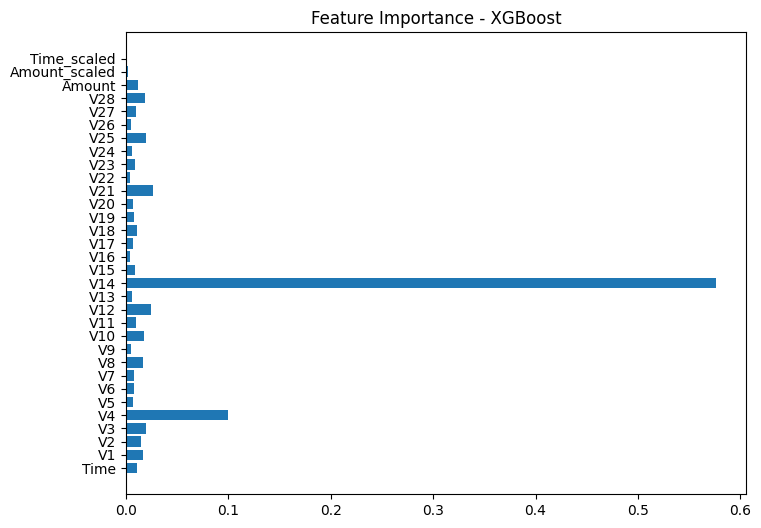

In [60]:
importances = xgb.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance - XGBoost")
plt.show()

In [61]:
results = pd.DataFrame({
    "Model": ["Logistic", "Poly LR", "Random Forest", "XGBoost"],
    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_poly),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results.sort_values(by="AUC", ascending=False))

           Model       AUC
3        XGBoost  0.981086
0       Logistic  0.968814
2  Random Forest  0.948845
1        Poly LR  0.939167


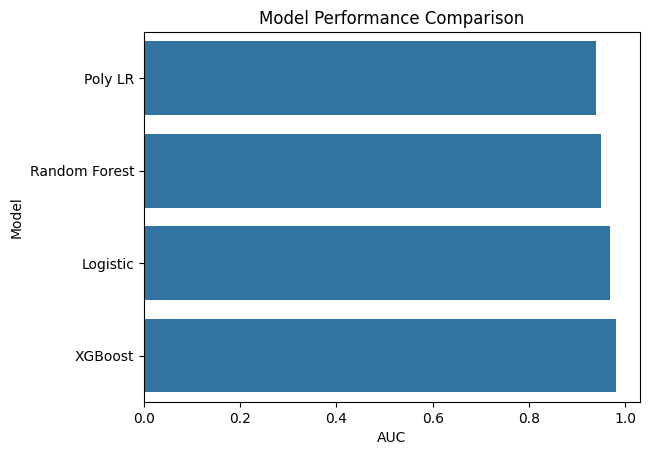

In [62]:
sns.barplot(x="AUC", y="Model", data=results.sort_values(by="AUC"))
plt.title("Model Performance Comparison")
plt.show()